<a href="https://colab.research.google.com/github/LukasHaussmann/2d-gaussian-splatting/blob/colab_oldinit/dtu_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#%cd content
!git clone -b colab_oldinit https://github.com/LukasHaussmann/2d-gaussian-splatting --recursive
!pip install plyfile

%cd /content/2d-gaussian-splatting/
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'
!pip install ninja
!pip install submodules/diff-surfel-rasterization
!pip install submodules/RoMa

!pip install open3d
!pip install mediapy
!pip install trimesh

# special measures to install simple-knn
# - explicitly including float.h because newer compilers reject implicit includes
%cd /content/2d-gaussian-splatting/submodules/simple-knn

# Add #include <float.h> to the top of the CUDA source file
!sed -i '1i #include <float.h>' simple_knn.cu  || sed -i '1i #include <float.h>' simple-knn.cu

# Install in editable mode
!pip install -q -e .

Cloning into '2d-gaussian-splatting'...
remote: Enumerating objects: 580, done.
remote: Counting objects: 100% (304/304), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 580 (delta 202), reused 157 (delta 130), pack-reused 276 (from 3)
Receiving objects: 100% (580/580), 12.10 MiB | 18.24 MiB/s, done.
Resolving deltas: 100% (313/313), done.
Submodule 'submodules/RoMa' (https://github.com/Parskatt/RoMa.git) registered for path 'submodules/RoMa'
Submodule 'submodules/depth_anything_v2' (https://github.com/DepthAnything/Depth-Anything-V2.git) registered for path 'submodules/depth_anything_v2'
Submodule 'submodules/diff-surfel-rasterization' (https://github.com/hbb1/diff-surfel-rasterization.git) registered for path 'submodules/diff-surfel-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/2d-gaussian-splatting/submodules/RoMa'...
remote: Enumerating object

**Import baseline 2DGS**

In [ ]:
# 1. Go to the root directory
%cd ~

# 2. Clone the official 2DGS repository (The Baseline)
# We use the recursive flag to make sure submodules like simple-knn are included
!git clone --recursive https://github.com/hbb1/2d-gaussian-splatting

# 3. Verify it exists
!ls ~/2d-gaussian-splatting

# 4. Go back to your project directory so you can run your evaluation script
%cd /content/2d-gaussian-splatting

/root
Cloning into '2d-gaussian-splatting'...
remote: Enumerating objects: 289, done.
remote: Counting objects: 100% (209/209), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 289 (delta 139), reused 87 (delta 87), pack-reused 80 (from 3)
Receiving objects: 100% (289/289), 9.41 MiB | 13.64 MiB/s, done.
Resolving deltas: 100% (145/145), done.
Submodule 'submodules/diff-surfel-rasterization' (https://github.com/hbb1/diff-surfel-rasterization.git) registered for path 'submodules/diff-surfel-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/root/2d-gaussian-splatting/submodules/diff-surfel-rasterization'...
remote: Enumerating objects: 697, done.        
remote: Counting objects: 100% (287/287), done.        
remote: Compressing objects: 100% (33/33), done.        
remote: Total 697 (delta 272), reused 254 (delta 254), pack-reused 410 (from 1)        
Receiving o

### New approach

In [ ]:
import shutil
import os

# --- DTU dataset ---

# 1. Define paths
drive_path = "/content/drive/MyDrive/ADL4CV/DTU_Data_Prepared/dtu.tar.gz"
local_path = "/content/dtu.tar.gz"
extract_path = "/content/"

# 2. Copy the file locally (much faster extraction later)
print("Copying file from Drive to local instance...")
shutil.copy(drive_path, local_path)

# 3. Create a directory for the data
os.makedirs(extract_path, exist_ok=True)

# 4. Extract
print("Extracting...")
# -x: extract
# -z: uncompress gzip
# -f: file
# -C: change directory to extract_path
!tar -xzf {local_path} -C {extract_path}

print(f"Extraction complete! Data is located at: {extract_path}")

Copying file from Drive to local instance...
Extracting...
Extraction complete! Data is located at: /content/


In [ ]:
# Ground truth data (necessary for eval)
!cp -r /content/drive/MyDrive/ADL4CV/DTU_Data_Prepared/SampleSet/MVS_Data /content
!cp -r /content/MVS_Data/Calibration /content/DTU
!cp -r /content/MVS_Data/ObsMask /content/DTU

!cp -r /content/drive/MyDrive/ADL4CV/DTU_Data_Prepared/Points.zip /content
!unzip /content/Points.zip -d /content/DTU
!cp -r /content/Points /content/DTU

Archive:  /content/Points.zip
   creating: /content/DTU/Points/
   creating: /content/DTU/Points/stl/
  inflating: /content/DTU/Points/stl/stl001_total.ply  
  inflating: /content/DTU/Points/stl/stl002_total.ply  
  inflating: /content/DTU/Points/stl/stl003_total.ply  
  inflating: /content/DTU/Points/stl/stl004_total.ply  
  inflating: /content/DTU/Points/stl/stl005_total.ply  
  inflating: /content/DTU/Points/stl/stl006_total.ply  
  inflating: /content/DTU/Points/stl/stl007_total.ply  
  inflating: /content/DTU/Points/stl/stl008_total.ply  
  inflating: /content/DTU/Points/stl/stl009_total.ply  
  inflating: /content/DTU/Points/stl/stl010_total.ply  
  inflating: /content/DTU/Points/stl/stl011_total.ply  
  inflating: /content/DTU/Points/stl/stl012_total.ply  
  inflating: /content/DTU/Points/stl/stl013_total.ply  
  inflating: /content/DTU/Points/stl/stl014_total.ply  
  inflating: /content/DTU/Points/stl/stl015_total.ply  
  inflating: /content/DTU/Points/stl/stl016_total.ply  
  

### New eval code

In [ ]:
# Install the virtual display tools
!apt-get update -q
!apt-get install -y xvfb libosmesa6-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,316 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,293 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.e

**Imports necessary for depth priors**
- NOTE: installing pytorch3d this way may take very long (15-30min)

In [ ]:
!pip install -q fvcore iopath
!pip install "git+https://github.com/facebookresearch/pytorch3d.git@stable"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/pytorch3d.git (to revision stable) to /tmp/pip-req-build-n8h_9b2k
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/pytorch3d.git /tmp/pip-req-build-n8h_9b2k
  Running command git checkout -q 75ebeeaea0908c5527e7b1e305fbc7681382db47
  Resolved https://github.com/facebookresearch/pytorch3d.git to commit 75ebeeaea0908c5527e7b1e305fbc7681382db47
  Preparing metadata (setup.py) ... done
  Created wheel for pytorch3d: filename=pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl size=64639777 sha256=c030f6a4488ce0d35999226e023b6e7e23ddc6e189d0353ec30f25100a27546d
  Stored in directory: /tmp/pip-ephem-wheel-cache-cgbqcxno/wheels/e9/ec/88/13a99edfc9de29485b221df3503c3bca62e23ab

In [ ]:
# 1. Install the package WITHOUT looking at its dependencies
!pip install --no-deps depth_anything_v2

# 2. Manually install ONLY the safe side-dependencies
# (Based on your logs, it needed these, but we don't want it touching torch or matplotlib)
!pip install gradio-imageslider

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
depth-anything-v2 0.1.0 requires matplotlib<4.0.0,>=3.10.3, but you have matplotlib 3.10.0 which is incompatible.
depth-anything-v2 0.1.0 requires torchvision<0.23.0,>=0.22.1, but you have torchvision 0.24.0+cu126 which is incompatible.


In [ ]:
import os

# 1. Create the expected directory
# The error says it looks in: submodules/depth_anything_v2/checkpoints/
checkpoint_dir = "/content/2d-gaussian-splatting/submodules/depth_anything_v2/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# 2. Download the model weights (ViT-Base version) from HuggingFace
# This matches the 'vitb' expected by the code
!wget -P {checkpoint_dir} https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth

# 3. Verify it's there
if os.path.exists(f"{checkpoint_dir}/depth_anything_v2_vitb.pth"):
    print("\nSUCCESS: Checkpoint downloaded!")
else:
    print("\nERROR: Download failed.")

--2026-01-29 12:30:57--  https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.40, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/666b1a774c61de4322ffeaef/6edb68314085b896936dd0ca275c81a4c7263b3a6850104562849bf8e9592298?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27depth_anything_v2_vitb.pth%3B+filename%3D%22depth_anything_v2_vitb.pth%22%3B&Expires=1769693458&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzY5NjkzNDU4fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjY2YjFhNzc0YzYxZGU0MzIyZmZlYWVmLzZlZGI2ODMxNDA4NWI4OTY5MzZkZDBjYTI3NWM4MWE0YzcyNjNiM2E2ODUwMTA0NTYyODQ5YmY4ZTk1OTIyOThcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signature=bnukBut40MsD

**Running evaluation compared to 2DGS**


In [ ]:
%cd /content/2d-gaussian-splatting/
# Use the virtual display wrapper
# -m means "run as module"
!xvfb-run python -m evaluation.run_evaluation \
    --scenes scan105 \
    --config evaluation/config/default_config.yaml #\
    #--dry-run

/content/2d-gaussian-splatting
Output directory: evaluation_results/fast_init_convergence_study
Scenes: ['scan105']
Time budgets: [120]
Iteration checkpoints: [1000, 2000]

TIME-BASED EVALUATION

################################################################################
# Time budget: 2min (120s)
################################################################################

--- Training scan105 with our method (2min) ---

Running: python train.py -s ../DTU/scan105 -m evaluation_results/fast_init_convergence_study/time_based/120s/ours/scan105 --matches_per_ref 15000 --nns_per_ref 3 --scaling_factor 0.001 --proj_err_tolerance 0.01 --normal_estimate_knn 20 --estimate_normals 1 --roma_model Indoor --position_lr_init 1.6e-05 --position_lr_final 1.6e-06 --position_lr_delay_mult 0.01 --position_lr_max_steps 30000 --feature_lr 0.0025 --opacity_lr 0.025 --scaling_lr 0.005 --rotation_lr 0.001 --percent_dense 0.01 --lambda_dssim 0.2 --lambda_dist 0.0 --lambda_normal 0.01 --densify_from_i

KeyboardInterrupt: 

**Running Parameter Ablation**

In [ ]:
%cd /content/2d-gaussian-splatting/
# Use the virtual display wrapper
!xvfb-run python -m evaluation.run_ablations --ablation depth_filtering \
      --scenes scan105 \
      --time-budgets 30

/content/2d-gaussian-splatting
Output directory: ablation_results
DTU source: ../DTU
Time budgets: [30]s
Scenes: ['scan105']
Resume: True

######################################################################
# Depth Filtering Ablation
######################################################################

Experiment: with_depth_filter
Parameter changes: {'initial_depth_pruning': 1}

--- with_depth_filter: scan105 (training up to 30s) ---
Running: python train.py -s ../DTU/scan105 -m ablation_results/depth_filtering/with_depth_filter/scan105 -r 2 --fast_init 1 --matches_per_ref 15000 --nns_per_ref 3 --scaling_factor 0.001 --proj_err_tolerance 0.01 --normal_estimate_knn 20 --estimate_normals 1 --initial_depth_pruning 1 --roma_model Indoor --iterations 5000 --position_lr_init 1.6e-05 --position_lr_final 1.6e-06 --position_lr_delay_mult 0.01 --position_lr_max_steps 30000 --feature_lr 0.0025 --opacity_lr 0.025 --scaling_lr 0.005 --rotation_lr 0.001 --percent_dense 0.01 --lambda_dssim 0.2 

**Save experiments**

In [ ]:
import shutil

# Zip the experiments folder
shutil.make_archive('depth_ablations', 'zip', 'ablation_results')

# Copy to Drive (Change 'MyDrive/' path if you want it somewhere specific)
!cp depth_ablations.zip /content/drive/MyDrive/ADL4CV/DTU_Runs/
print("Results saved to Drive!")

Results saved to Drive!


**optional clean-up cell**

In [ ]:
# deleting experiments files for new runs to prevent overlaps/errors
%cd /content/2d-gaussian-splatting/
!rm -rf dtu_scans_evaluation/scan24/

/content/2d-gaussian-splatting


### Compare

In [ ]:
%cd /content/2d-gaussian-splatting
!mkdir experiments

/content/2d-gaussian-splatting


In [ ]:
#!cp /content/drive/MyDrive/ADL4CV/DTU_Runs/scan24_densify_no_pruning_experiments.zip /content/
#!unzip /content/scan24_densify_no_pruning_experiments.zip -d /content/2d-gaussian-splatting/experiments/e2

#!cp /content/drive/MyDrive/ADL4CV/DTU_Runs/prune_densify_ablation_300s.zip /content/
!unzip /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations.zip -d /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations

Archive:  /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations.zip
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/no_depth_filter/
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/no_depth_filter_no_opacity_tuning/
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/no_opacity_tuning/
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/with_depth_filter/
  inflating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/results.csv  
  inflating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/config.yaml  
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/no_opacity_tuning/105/
   creating: /content/drive/MyDrive/ADL4CV/DTU_Runs/depth_ablations/depth_filtering/no_opacity_tuning/scan105/
  infl

/content/2d-gaussian-splatting/experiments/densify_until_iter_scan24
Found 0 files to plot: []


/tmp/ipython-input-1069070122.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


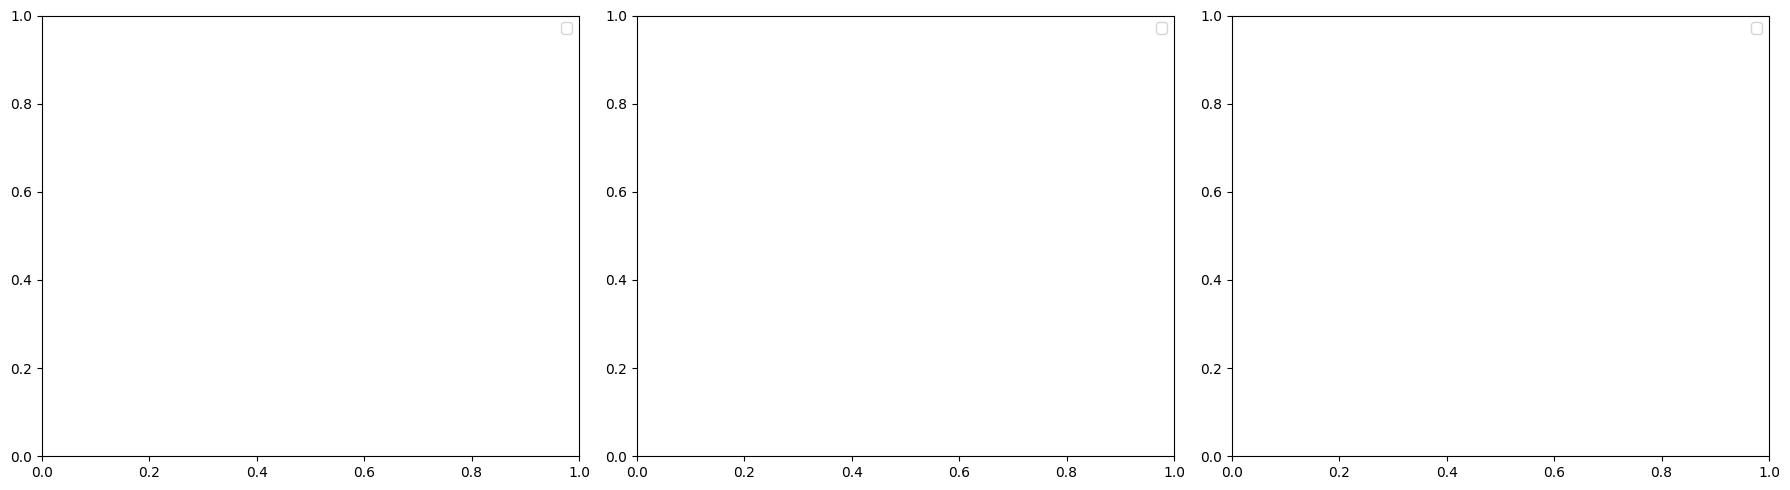

In [ ]:
%cd /content/2d-gaussian-splatting/experiments/densify_until_iter_scan24
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# 1. Find all CSV files in the current directory
csv_files = glob.glob("*.csv")

# 2. Set up the figure with 3 subplots (one for each metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['accuracy', 'completeness', 'overall']

print(f"Found {len(csv_files)} files to plot: {csv_files}")

for file_path in csv_files:
    try:
        # 'sep=None, engine="python"' automatically detects if it's comma or space separated
        df = pd.read_csv(file_path, sep=None, engine='python')

        # Clean up column names (remove extra whitespace just in case)
        df.columns = df.columns.str.strip()

        # Ensure 'iterations' exists
        if 'iterations' not in df.columns:
            print(f"Skipping {file_path}: 'iterations' column not found.")
            continue

        # Sort by iterations to ensure the line is drawn strictly left-to-right
        df = df.sort_values('iterations')

        # Get a clean label name from the filename
        label_name = os.path.basename(file_path)

        # 3. Plot each metric on its respective subplot
        for i, metric in enumerate(metrics):
            if metric in df.columns:
                axes[i].plot(df['iterations'], df[metric], marker='.', label=label_name)
                axes[i].set_title(metric.capitalize())
                axes[i].set_xlabel('Iterations')
                axes[i].set_ylabel('Score')
                axes[i].grid(True, linestyle='--', alpha=0.6)

    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# 4. Add legends and show the plot
for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

**Error Map Code**

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_error_map(experiment_path, iteration=7000, num_samples=3):
    """
    Visualizes the difference between Rendered and Ground Truth images.
    """
    # 1. Construct Paths
    # Adjust "train" to "test" if you want to see test views,
    # but "train" usually contains the views used for optimization.
    render_path = os.path.join(experiment_path, f"train/ours_{iteration}/renders")
    gt_path = os.path.join(experiment_path, f"train/ours_{iteration}/gt")

    # 2. Safety Checks
    if not os.path.exists(render_path):
        print(f"Error: Could not find renders at {render_path}")
        return

    # 3. Get Files
    files = sorted(os.listdir(render_path))
    if len(files) == 0:
        print("No images found.")
        return

    # Select specific images (e.g., every 10th image to get variety)
    step = max(1, len(files) // num_samples)
    selected_files = files[::step][:num_samples]

    # 4. Plot
    fig, axes = plt.subplots(len(selected_files), 3, figsize=(15, 4 * len(selected_files)))
    if len(selected_files) == 1: axes = [axes] # Handle single row case

    print(f"Visualizing Error Maps for: {experiment_path}")

    for i, filename in enumerate(selected_files):
        # Load and Normalize (0.0 to 1.0)
        try:
            img_r = np.array(Image.open(os.path.join(render_path, filename))) / 255.0
            img_g = np.array(Image.open(os.path.join(gt_path, filename))) / 255.0
        except Exception as e:
            print(f"Failed to load {filename}: {e}")
            continue

        # --- THE MAGIC CALCULATION ---
        # Absolute difference averaged across RGB channels
        diff = np.abs(img_r - img_g).mean(axis=2)
        # -----------------------------

        # Column 1: Render
        ax_r = axes[i][0] if len(selected_files) > 1 else axes[0]
        ax_r.imshow(img_r)
        ax_r.set_title(f"Render (Iter {iteration})")
        ax_r.axis('off')

        # Column 2: Ground Truth
        ax_g = axes[i][1] if len(selected_files) > 1 else axes[1]
        ax_g.imshow(img_g)
        ax_g.set_title("Ground Truth")
        ax_g.axis('off')

        # Column 3: Error Heatmap
        ax_e = axes[i][2] if len(selected_files) > 1 else axes[2]
        # vmin=0, vmax=0.3 emphasizes subtle errors.
        # Increase vmax to 1.0 if errors are massive.
        im = ax_e.imshow(diff, cmap='jet', vmin=0, vmax=0.3)
        ax_e.set_title("Error Map (The 'Fire')")
        ax_e.axis('off')

        # Colorbar
        plt.colorbar(im, ax=ax_e, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Use the path to your BEST experiment from the sweep (the 0.005 one)
# or the one with holes you want to analyze.
# Update the path below to match your folder structure:
%cd content/2d-gaussian-splatting
experiment_path = "experiments/densify_until_iter_scan24/densify_until_iter=1000"

visualize_error_map(experiment_path, iteration=3000, num_samples=3)

[Errno 2] No such file or directory: 'content/2d-gaussian-splatting'
/content/2d-gaussian-splatting/submodules/simple-knn
Error: Could not find renders at experiments/densify_until_iter_scan24/densify_until_iter=1000/train/ours_3000/renders
